In [1]:
import os
os.chdir('Astronet-Triage')  # Change to the 'Astronet-Triage' folder

# chkpt_root = '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid_base_new_2500' # Pablo Jan 25
# data_files = '../mnt/tess/astronet/tfrecords-vetting-v01-include-centroiddist-test*'
# tces_file = '../mnt/tess/astronet/tces-vetting-v02-include-centroiddist-test.csv'
# file_pattern = '../mnt/tess/astronet/tfrecords-vetting-v02-include-centroiddist-test/*'


# data_files = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-test/*' # tried adding a /
# tces_file = '../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-test.csv'
# file_pattern = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-test/*'

# Feb 2025 - Evaluating new model on all periods of the test set
# chkpt_root='../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v2_base_new_2500'

# data_files = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v2-test/*'
# tces_file = '../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v2-test.csv'
# file_pattern = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v2-test*'

# Feb 2025 - Reevaluating the model from the previous run

# chkpt_root = '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid_base_new_2500' # Pablo Jan 25
# data_files = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-test/*' # tried adding a /
# tces_file = '../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-test.csv'
# file_pattern = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-test/*'

# Feb 2025 - Evaluating the old model on the new test set

# chkpt_root = '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid_base_new_2500' # Pablo Jan 25
# data_files = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v2-test/*'
# tces_file = '../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v2-test.csv'
# file_pattern = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v2-test*'


#Feb 2025, Evaluating the third and final training run on its own test set
chkpt_root = '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500' # Pablo Jan 25
data_files = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-test/*'
tces_file = '../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-test.csv'
file_pattern = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-test*'

#Feb 2025, Evaluating the old training run on the new test set
# chkpt_root = '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid_base_new_2500' # Pablo Jan 25
# data_files = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-test/*'
# tces_file = '../mnt/tess/astronet/tces-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-test.csv'
# file_pattern = '../mnt/tess/astronet/tfrecords-vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle-test*'


labels = ['p', 'e', 'n', 'j']

nruns = 10

def load_ensemble(chkpt_root, nruns):
    checkpts = []

    for i in range(nruns):
        parent = os.path.join(chkpt_root, str(i + 1))
        if not os.path.exists(parent):
            print(f'Couldnt find checkpoint {parent}')
            break
        all_dirs = os.listdir(parent)
        if not all_dirs:
            break
        d, = all_dirs
        checkpts.append(os.path.join(parent, d))
    return checkpts

paths = load_ensemble(chkpt_root, nruns)
paths

['../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500/1/AstroCNNModelVetting_base_new_20250221_112434',
 '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500/2/AstroCNNModelVetting_base_new_20250221_112843',
 '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500/3/AstroCNNModelVetting_base_new_20250221_113154',
 '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500/4/AstroCNNModelVetting_base_new_20250221_113523',
 '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500/5/AstroCNNModelVetting_base_new_20250221_113835',
 '../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500/6/AstroCNNModelVetting_base_new_20250221_114149',
 '../mnt/tess/astronet/check

In [2]:
import getpass
import os
from astronet import predict
import tensorflow as tf
# os.chdir('Astronet-Triage')  # Change to the 'Astronet-Triage' folder

def run_predictions(path):
    # predict.FLAGS = predict.parser.parse_args([
    #   '--model_dir', path,
    #   '--data_files', data_files,
    #   '--output_file', '',
    # ])

    return predict.predict(model_dir=path, data_files=data_files, output_file=None)


paths = load_ensemble(chkpt_root, nruns)
ensemble_preds = []
config = None
for i, path in enumerate(paths):
    print(f'Running model {i + 1}')
    print('path:', path)
    preds, config = run_predictions(path)
    ensemble_preds.append(preds.set_index('astro_id'))
    print()


2025-03-14 09:59:21.111944: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-14 09:59:22.377450: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Running model 1
path: ../mnt/tess/astronet/checkpoints/vetting-v01-tois-triageJs-nocentroid-newTOIs2025-v3-noreshufle_base_new_2500/1/AstroCNNModelVetting_base_new_20250221_112434


2025-03-14 09:59:29.116396: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 179 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:05:00.0, compute capability: 8.6
2025-03-14 09:59:29.118234: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46196 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6
2025-03-14 09:59:29.119343: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46196 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6
2025-03-14 09:59:29.120377: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1635] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 46196 MB memory:  -> device: 3, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, co

0 records

2025-03-14 09:59:32.235675: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5]
	 [[{{node Placeholder/_0}}]]
2025-03-14 09:59:34.442312: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:219] failed to create cublas handle: the library was not initialized
2025-03-14 09:59:34.442385: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:222] Failure to initialize cublas may be due to OOM (cublas needs some free memory when you initialize it, and your deep-learning framework may have preallocated more than its fair share), or may be because this binary was not built with support for the GPU in your machine.
2025-03-14 09:59:34.442449: W tensorflow/core/framework/op_kernel.cc:1830] OP_REQUIRES failed at conv_ops.cc:786 : INTERNAL: Attempting to 

InternalError: Graph execution error:

Detected at node 'separable_conv2d' defined at (most recent call last):
Node: 'separable_conv2d'
Attempting to perform BLAS operation using StreamExecutor without BLAS support
	 [[{{node separable_conv2d}}]] [Op:__inference_restored_function_body_13517]

In [5]:
import pandas as pd

In [1]:
ensemble_preds


NameError: name 'ensemble_preds' is not defined

In [5]:

# # Write to Excel
# with pd.ExcelWriter("ensemble_preds_feb2025trainigrun.xlsx") as writer:
#     for i, df in enumerate(ensemble_preds):
#         df.to_excel(writer, sheet_name=f"model_{i}")

# # Read back
# ensemble_preds = []
# xls = pd.ExcelFile("ensemble_preds_feb2025trainingrun.xlsx")
# for sheet_name in xls.sheet_names:
#     ensemble_preds.append(pd.read_excel(xls, sheet_name=sheet_name))




# #Write to CSV
# for i, df in enumerate(ensemble_preds):
#     df.to_csv(f"ensemble_preds/model_{i}.csv", index=True)

# ensemble_preds = []
# for i in range(10):
#     ensemble_preds.append(pd.read_csv(f"ensemble_preds/model_{i}.csv"))


#Write to CSV plus zip

import os
import pandas as pd
import shutil

# Ensure the directory exists
os.makedirs("ensemble_preds", exist_ok=True)

# Save CSV files
for i, df in enumerate(ensemble_preds):
    df.to_csv(f"ensemble_preds/model_{i}.csv", index=True)

# Reload CSV files
ensemble_preds = []
for i in range(10):
    ensemble_preds.append(pd.read_csv(f"ensemble_preds/model_{i}.csv"))

# Zip the folder
shutil.make_archive("ensemble_preds", 'zip', "ensemble_preds")

print("Folder 'ensemble_preds' has been zipped as 'ensemble_preds.zip'.")


Folder 'ensemble_preds' has been zipped as 'ensemble_preds.zip'.


In [3]:
print(type(ensemble_preds), len(ensemble_preds), ensemble_preds[0].shape, type(ensemble_preds[0]))
ensemble_preds[0].head()

<class 'list'> 10 (1073, 4) <class 'pandas.core.frame.DataFrame'>


,disp_p,disp_e,disp_n,disp_j
astro_id,,,,
5916,0.998571,0.000437,0.000158,0.000833
10164,0.983175,0.001657,0.001802,0.013366
10772,0.999726,0.000033,0.000012,0.000228
1105,0.156792,0.839934,0.001604,0.001671
2415,0.052239,0.943570,0.002148,0.002043


In [8]:
ensemble_preds[0].columns[0]

'disp_p'

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_and_plot_correlation(models_scores):
    """
    Compute and plot correlation matrices for a 4-class classification problem.

    Parameters:
    models_scores (list of np.array): A list containing 10 arrays of shape (1071, 4),
                                      representing the scores of each model for each class.
    """
    num_models = len(models_scores)
    num_classes = models_scores[0].shape[1]  # Should be 4

    # Convert to shape (1071, 10, 4), where axis 1 corresponds to models
    scores_array = np.stack(models_scores, axis=1)  # Shape: (1071, 10, 4)

    fig, axes = plt.subplots(1, num_classes, figsize=(20, 5))

    for class_idx in range(num_classes):
        # Extract scores for the current class -> Shape: (1071, 10)
        class_scores = scores_array[:, :, class_idx]

        # Compute the correlation matrix
        correlation_matrix = np.corrcoef(class_scores, rowvar=False)  # Shape: (10,10)

        # Plot
        ax = axes[class_idx]
        sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="Blues", ax=ax)
        ax.set_title(f'Class {models_scores[0].columns[class_idx]} Correlation Matrix')
        ax.set_xlabel("Models")
        ax.set_ylabel("Models")

    plt.tight_layout()
    plt.show()

# Example usage (assuming models_scores is a list of 10 numpy arrays of shape (1071,4))
# compute_and_plot_correlation(models_scores)

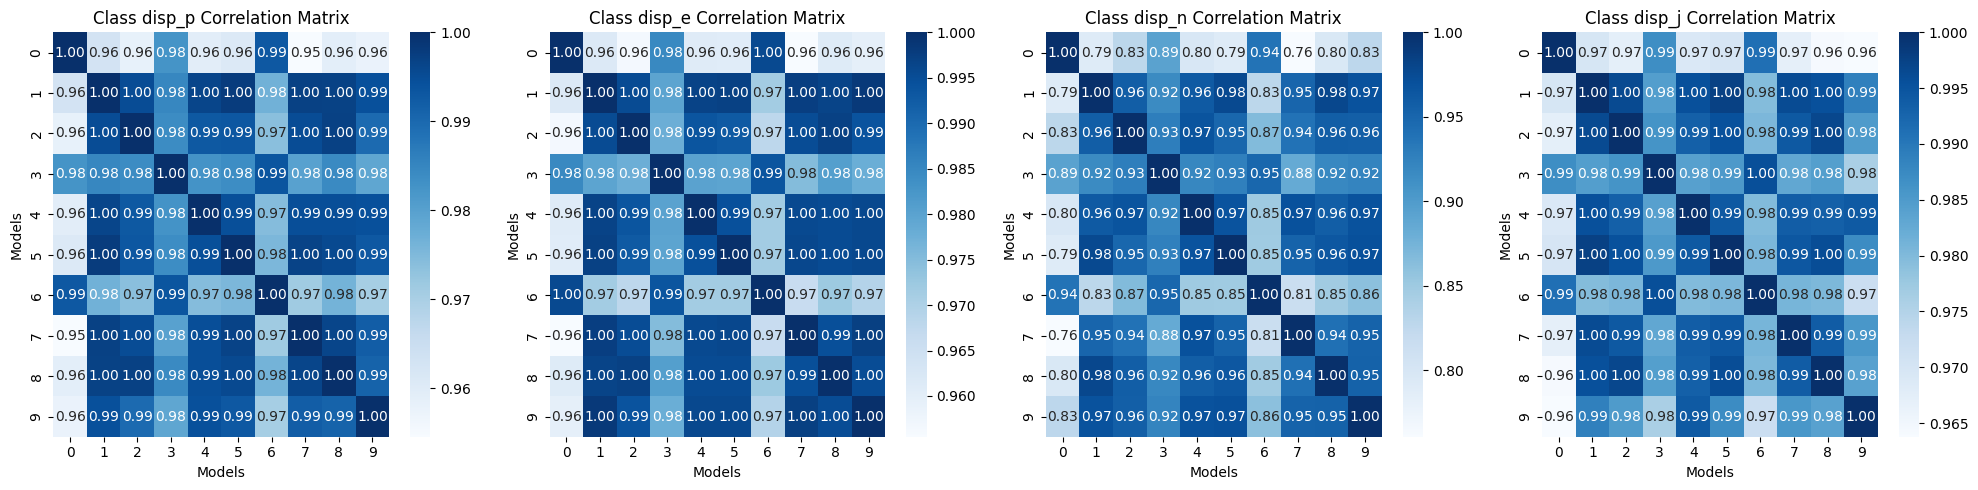

In [15]:
compute_and_plot_correlation(ensemble_preds)

In [4]:
labels = ['disp_p', 'disp_e', 'disp_n', 'disp_j']

col_e = labels.index('disp_e')
thresh = 0.215

In [5]:
import numpy as np
import pandas as pd

agg_preds = {}

# Ensemble predictions are a list of DataFrames for each model
# Each preds is a DataFrame
for preds in ensemble_preds:
    # For each example in the predictions, ex_id is the astro_id
    for ex_id in preds.index:
        if ex_id not in agg_preds:
            agg_preds[ex_id] = []

        row = preds[preds.index == ex_id]
        # row is a DataFrame with one row containing astro_id and the predictions for disp_p, disp_e, disp_n, disp_j
        # row has shape (1, 4)
        pred_v = row.values[0]
        # pred_v is a numpy array of shape (4,) containing the predictions for disp_p, disp_e, disp_n, disp_j

        if len(row.values) > 1:
            print(f'Warning: duplicate predictions for {ex_id}')

        if pred_v[col_e] >= thresh:
            # if the prediction for disp_e is greater than the threshold, append 'disp_e' to the list of predictions for this example
            agg_preds[ex_id].append('disp_e')

        else:
            # if the prediction for disp_e is less than the threshold, append the class with the highest prediction to the list of predictions for this example
            # - This list replaces the value at index `col_e` with 0 while keeping the rest unchanged.
            masked_v = [v if i != col_e else 0 for i, v in enumerate(pred_v)]
            # - Append the label corresponding to the highest prediction to the list of predictions for this example
            agg_preds[ex_id].append(preds.columns[np.argmax(masked_v)])

In [6]:
#Optional: Visualize instances of agg_preds where not all labels are the same each entry in agg_preds has 10 labels
list_of_unequal_preds = []
for k, v in agg_preds.items():
    if len(set(v)) != 1:
        list_of_unequal_preds.append((k, v))
        # print(k, v)
print(len(list_of_unequal_preds), 'out of', len(agg_preds), 'instances have unequal predictions')


57 out of 1073 instances have unequal predictions


In [7]:
final_preds = []
for ex_id in list(agg_preds.keys()):
    counts = {l: 0 for l in labels}
    for e in agg_preds[ex_id]:
        counts[e] += 1
    maxcount = max(counts.values())
    counts.update({
        'astro_id': ex_id,
        'maxcount': maxcount,
    })
    # print(counts)
    final_preds.append(counts)

final_preds = pd.DataFrame(final_preds).set_index('astro_id')
final_preds.head()

,disp_p,disp_e,disp_n,disp_j,maxcount
astro_id,,,,,
5916,10,0,0,0,10
10164,0,0,0,10,10
10772,0,0,0,10,10
1105,0,10,0,0,10
2415,0,10,0,0,10


In [8]:
# Read the TCE table from the test set csv file
tce_table = pd.read_csv(tces_file, header=0, low_memory=False)
tce_table['astro_id'] = tce_table['Astro ID']
tce_table = tce_table.set_index('astro_id')
for l in labels:
    tce_table[l] = tce_table[l[:-1] + l[-1]]
# keep only the columns with the labels and the TIC ID
tce_labels = tce_table[labels + ['TIC ID']]

# Join the final predictions with the TCE labels on the astro_id
pl = final_preds.join(tce_labels, on='astro_id', how='left', lsuffix='_pred')


pd.set_option('display.max_columns', None)
pl.head()

,disp_p_pred,disp_e_pred,disp_n_pred,disp_j_pred,maxcount,disp_p,disp_e,disp_n,disp_j,TIC ID
astro_id,,,,,,,,,,
5916,10,0,0,0,10,1,0,0,0,180931993
10164,0,0,0,10,10,1,0,0,0,400515645
10772,0,0,0,10,10,1,0,0,0,243030574
1105,0,10,0,0,10,0,1,0,0,323685904
2415,0,10,0,0,10,0,1,0,0,233554200


In [9]:
# ppos = (pl['disp_e_pred'] > 0)
# pos = (pl['disp_e'] > 0)

# pneg = (pl['disp_e_pred'] == 0)
# neg = (pl['disp_e'] == 0)

# print('Recall:', len(pl[ppos & pos]) / len(pl[pos]))
# print('Precision:', len(pl[ppos & pos]) / len(pl[ppos]))


#Made the code more readable
# Define conditions for TP, FP, TN, and FN
TP = ((pl['disp_e_pred'] > 0) & (pl['disp_e'] > 0)).sum()
FP = ((pl['disp_e_pred'] > 0) & (pl['disp_e'] == 0)).sum()
TN = ((pl['disp_e_pred'] == 0) & (pl['disp_e'] == 0)).sum()
FN = ((pl['disp_e_pred'] == 0) & (pl['disp_e'] > 0)).sum()

# Calculate precision and recall
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Print results
print('TP:', TP)
print('FP:', FP)
print('TN:', TN)
print('FN:', FN)
print('Recall:', recall)
print('Precision:', precision)

TP: 336
FP: 56
TN: 672
FN: 9
Recall: 0.9739130434782609
Precision: 0.8571428571428571


In [10]:
# Print the false positives
print('False positive TIC IDs:')
false_positives = pl[(pl['disp_e_pred'] > 0) & (pl['disp_e'] == 0)]  # Correct filtering for FP

for index, row in false_positives.iterrows():  # Iterate over DataFrame rows
    tic_id = row['TIC ID']
    period = tce_table.loc[index, 'Per']  # Access period using the index
    print(f'TIC ID {tic_id} with period {period}')


False positive TIC IDs:
TIC ID 44737596 with period 2.788654032
TIC ID 369327273 with period 5.991114
TIC ID 37718056 with period 3.656957622
TIC ID 328984640 with period 0.620816
TIC ID 331846118 with period 3.118742
TIC ID 119153127 with period 0.5593023587
TIC ID 111991770 with period 3.752553367
TIC ID 116608612 with period 3.455851649
TIC ID 229510866 with period 2.102935
TIC ID 105379013 with period 3.295514393
TIC ID 263723781 with period 6.5433068
TIC ID 159894133 with period 44.35367
TIC ID 349503728 with period 1.1235117
TIC ID 74885707 with period 0.3743
TIC ID 63082902 with period 10.298566
TIC ID 101496204 with period 0.63819
TIC ID 269217040 with period 4.166126528
TIC ID 317670803 with period 0.248605
TIC ID 206669860 with period 10.0614092
TIC ID 266769513 with period 0.53501
TIC ID 164520007 with period 15.37033
TIC ID 154814765 with period 26.1442304
TIC ID 289389326 with period 1.7988855
TIC ID 298049015 with period 3.9131371
TIC ID 442857414 with period 0.770155
TIC

In [11]:
# Print the false negatives
print('False negative TIC IDs:')
false_negatives = pl[(pl['disp_e_pred'] == 0) & (pl['disp_e'] > 0)]  # Correct filtering for FN

for index, row in false_negatives.iterrows():  # Iterate over DataFrame rows
    tic_id = row['TIC ID']
    period = tce_table.loc[index, 'Per']  # Access period using the index
    print(f'TIC ID {tic_id} with period {period}')


False negative TIC IDs:
TIC ID 15565627 with period 3.804773138
TIC ID 15247229 with period 8.512351779
TIC ID 9858404 with period 0.3917077032
TIC ID 306919011 with period 1.594337
TIC ID 300291839 with period 9.250459633
TIC ID 341557177 with period 9.389976
TIC ID 29781865 with period 6.860309
TIC ID 55452495 with period 17.7075863
TIC ID 442942829 with period 2.944938


In [12]:
# for i in pl[pos & pneg]['TIC ID']:
#     print(i)

# for i in pl[neg & ppos]['TIC ID']:
#     print(i)

In [13]:
#Code to look at the predictions of the ensemble models for a specific TIC ID
# The filter is the index of the TIC ID in the predictions DataFrame
# The compare function takes the ensemble predictions and the filter and returns the predictions for the TIC ID
# in each of the ensemble models
def compare(ensemble_preds, filter):
    result=[]
    for preds in ensemble_preds[1:]:
        result.append(preds[filter])
    return result

compare(ensemble_preds, preds.index==pl[pl['TIC ID'] == 36734222].index.values[0])

IndexError: index 0 is out of bounds for axis 0 with size 0

In [15]:
tce_labels

,disp_p,disp_e,disp_n,disp_j,TIC ID
astro_id,,,,,
10948,1,0,0,0,263723781
27578,0,0,0,1,279647620
10236,1,0,0,0,428703516
26900,0,0,0,1,178641381
145,0,1,0,0,141685465
...,...,...,...,...,...
734,1,0,0,0,257642093
6291,1,0,0,0,229490898
6903,1,0,0,0,271307949


### PR curve

In [16]:
col_e

1

In [17]:
ids = set(ensemble_preds[0].index.values)

index = {v: i for i, v in enumerate(ids)}

#Make a matrix of the ensemble predictions N x M where N is the number of models and M is the number of examples in the test set
pred_es = np.zeros([len(ensemble_preds), len(index)])

for i, preds in enumerate(ensemble_preds):
    for row in preds.iterrows():
        ex_id, pred_e = row[0], row[1][col_e]
        pred_es[i][index[ex_id]] = pred_e

lbl_es = np.zeros([len(index)], dtype=bool)
for row in tce_labels.iterrows():
    ex_id, lbl_e = row[0], row[1]['disp_e']
    try:
        lbl_es[index[ex_id]] = (lbl_e > 0)
    except Exception as e:
        print("ERROR: Did not have ID", e)
        continue

In [18]:
pred_es[:,5], lbl_es[5]

(array([0.01464409, 0.02592871, 0.04258813, 0.02946653, 0.08302115,
        0.03047842, 0.09126416, 0.01711605, 0.04638786, 0.11388324]),
 False)

In [19]:
num_cond_pos = int(np.sum(lbl_es))

def pr_rc_at_th(th):
    pred_pos = np.any(pred_es >= th, axis=0)
    true_pos = pred_pos & lbl_es
    num_pred_pos = int(np.sum(pred_pos))
    num_true_pos = int(np.sum(true_pos))
    if num_pred_pos == 0:
        return 1.0, 0.0
    return float(num_true_pos) / float(num_pred_pos), float(num_true_pos) / float(num_cond_pos)

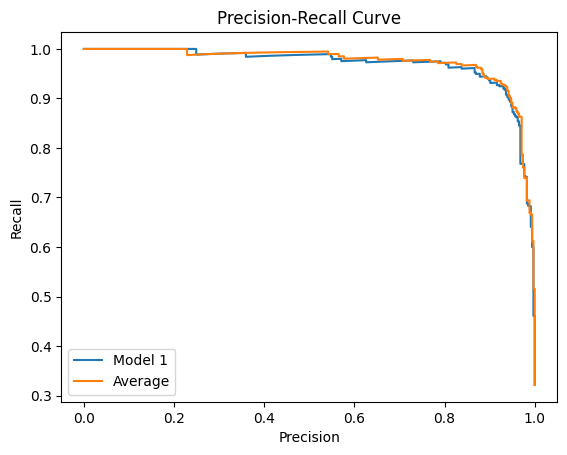

In [20]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(lbl_es, pred_es[0])
precision_2, recall_2, thresholds = precision_recall_curve(lbl_es, np.mean(pred_es, axis=0))

plt.plot(recall, precision, label='Model 1')
plt.xlabel("Precision")
plt.ylabel("Recall")

plt.plot(recall_2, precision_2, label='Average')

plt.legend()
plt.title('Precision-Recall Curve')

plt.show()


In [21]:
tce_labels

,disp_p,disp_e,disp_n,disp_j,TIC ID
astro_id,,,,,
10948,1,0,0,0,263723781
27578,0,0,0,1,279647620
10236,1,0,0,0,428703516
26900,0,0,0,1,178641381
145,0,1,0,0,141685465
...,...,...,...,...,...
734,1,0,0,0,257642093
6291,1,0,0,0,229490898
6903,1,0,0,0,271307949


Text(0.5, 1.0, 'Confusion Matrix')

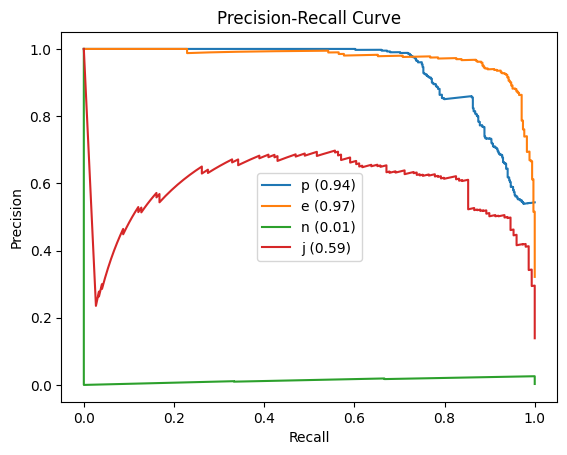

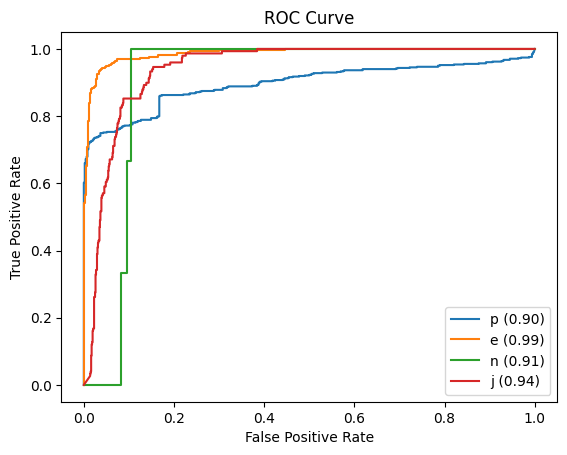

<Figure size 640x480 with 0 Axes>

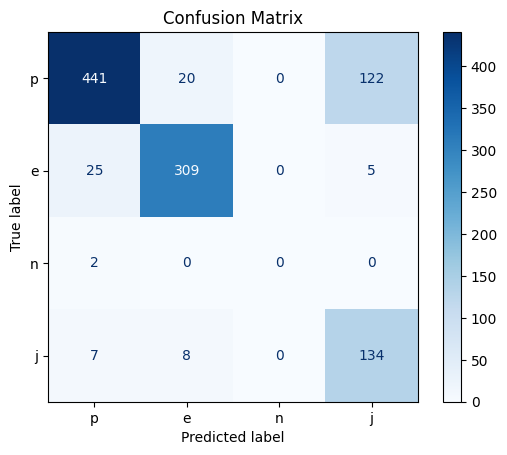

In [22]:
# Make PR curve with Scikit learn

from sklearn.metrics import precision_recall_curve, roc_curve, confusion_matrix, auc
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay


# i = 0 # i is the ensemble idx out of 10

ytrue = []
ypred = []
astro_id_preds = []
tic_id_preds = []
for astro_id in tce_labels.index:
    try:
        # ypred.append(np.max(np.array([ensemble_preds[i].loc[astro_id].values for i in range(nruns)]), axis=0)) # i is the ensemble idx out of 10
        ypred.append(np.mean(np.array([ensemble_preds[i].loc[astro_id].values for i in range(nruns)]), axis=0))

        ytrue.append(tce_labels.loc[astro_id].values[:-1])

        astro_id_preds.append(astro_id)
        tic_id_preds.append(tce_labels.loc[astro_id].values[-1])
        # ypred.append(ensemble_preds[i].loc[astro_id].values)
    except Exception as e:
        print("ERROR: No object.", e)
        continue


ytrue = np.array(ytrue).astype(bool)
ypred = np.array(ypred)

# PR curve
plt.figure()
for l, label in enumerate(labels):
    precision, recall, thresholds = precision_recall_curve(ytrue[:,l], ypred[:,l])
    auc_val = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label.split('_')[-1]} ({auc_val:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title('Precision-Recall Curve')

# ROC curve
plt.figure()
for l, label in enumerate(labels):
    fpr, tpr, thresholds = roc_curve(ytrue[:,l], ypred[:,l])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label.split('_')[-1]} ({auc_val:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title('ROC Curve')

# Confusion Matrix
plt.figure()
cm = confusion_matrix(ytrue.argmax(axis=1),ypred.argmax(axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label.split('_')[-1] for label in labels])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')


/pdo/users/pablomer/miniconda3/envs/daniel_env_cloned_v2/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:979: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/pdo/users/pablomer/miniconda3/envs/daniel_env_cloned_v2/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:1132: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (4).

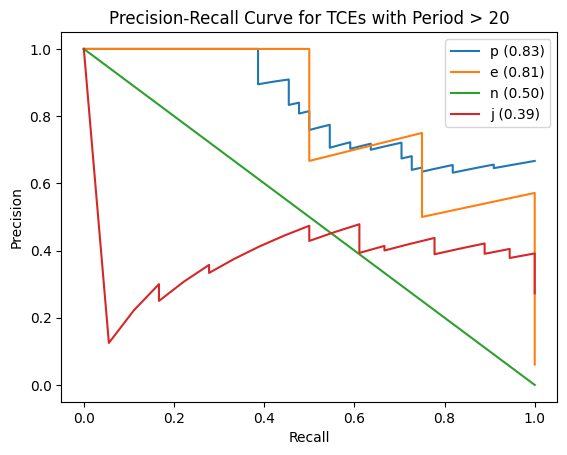

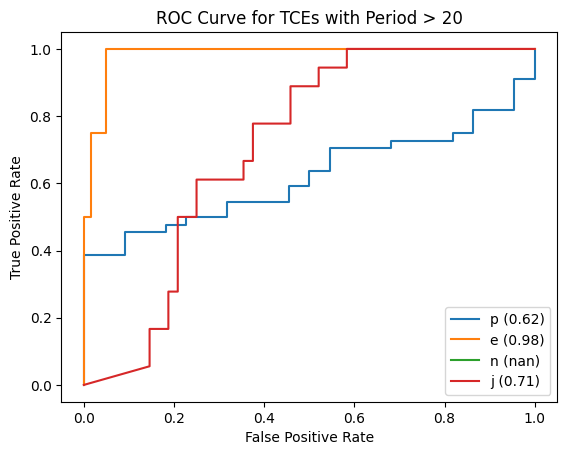

<Figure size 640x480 with 0 Axes>

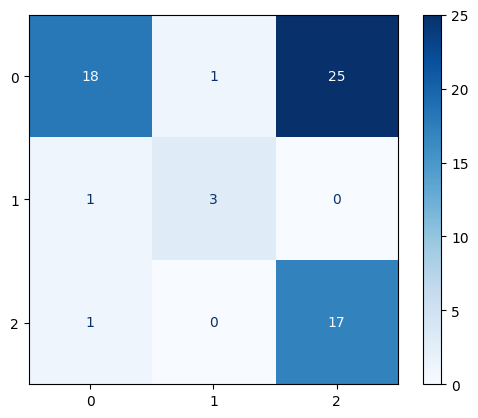

In [25]:
# Extra: Make the Precision Recall and Confusion matrix only for elements with long periods

# Make PR curve with Scikit learn

from sklearn.metrics import precision_recall_curve, roc_curve, confusion_matrix, auc
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay

# Create a boolean mask for rows where 'Per' > 20 for each Astro ID in tce_labels
long_period=20
mask = tce_table.loc[tce_labels.index, 'Per'] > long_period
filtered_tce_labels = tce_labels[mask]

# i = 0 # i is the ensemble idx out of 10

ytrue_long = []
ypred_long = []
astro_id_preds = []
tic_id_preds = []
for astro_id in filtered_tce_labels.index:
    try:
        # ypred.append(np.max(np.array([ensemble_preds[i].loc[astro_id].values for i in range(nruns)]), axis=0)) # i is the ensemble idx out of 10
        ypred_long.append(np.mean(np.array([ensemble_preds[i].loc[astro_id].values for i in range(nruns)]), axis=0))

        ytrue_long.append(tce_labels.loc[astro_id].values[:-1])

        astro_id_preds.append(astro_id)
        tic_id_preds.append(tce_labels.loc[astro_id].values[-1])
        # ypred.append(ensemble_preds[i].loc[astro_id].values)
    except Exception as e:
        print("ERROR: No object.", e)
        continue


ytrue_long = np.array(ytrue_long).astype(bool)
ypred_long = np.array(ypred_long)

# PR curve
plt.figure()
for l, label in enumerate(labels):
    precision, recall, thresholds = precision_recall_curve(ytrue_long[:,l], ypred_long[:,l])
    auc_val = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label.split('_')[-1]} ({auc_val:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title('Precision-Recall Curve for TCEs with Period > 20')

# ROC curve
plt.figure()
for l, label in enumerate(labels):
    fpr, tpr, thresholds = roc_curve(ytrue_long[:,l], ypred_long[:,l])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label.split('_')[-1]} ({auc_val:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title('ROC Curve for TCEs with Period > 20')

# # Confusion Matrix
# plt.figure()
# cm = confusion_matrix(ytrue.argmax(axis=1),ypred.argmax(axis=1))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label.split('_')[-1] for label in labels])
# disp.plot(cmap=plt.cm.Blues)
# plt.title('Confusion Matrix for TCEs with Period > 20')


# Confusion Matrix
plt.figure()
cm = confusion_matrix(ytrue_long.argmax(axis=1), ypred_long.argmax(axis=1))

# Get unique classes present in the filtered data
present_classes = np.unique(ytrue.argmax(axis=1))
filtered_labels = [labels[i].split('_')[-1] for i in present_classes]  # Filter only present class labels

# Plot the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=filtered_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for TCEs with Period > 20')


Text(0.5, 1.0, 'Confusion Matrix for TCEs with Period < 20')

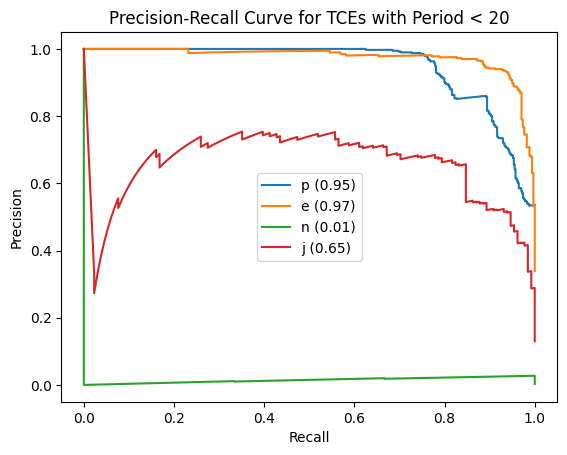

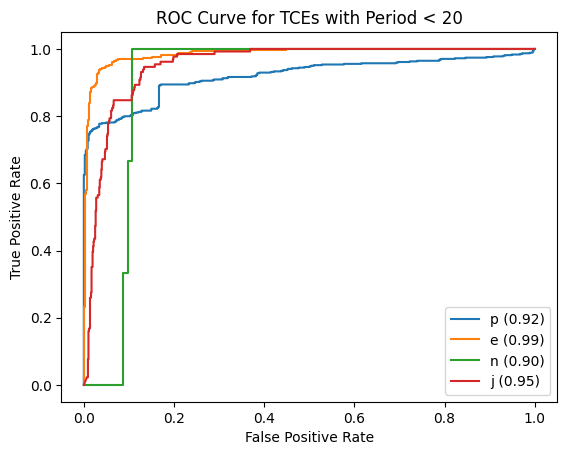

<Figure size 640x480 with 0 Axes>

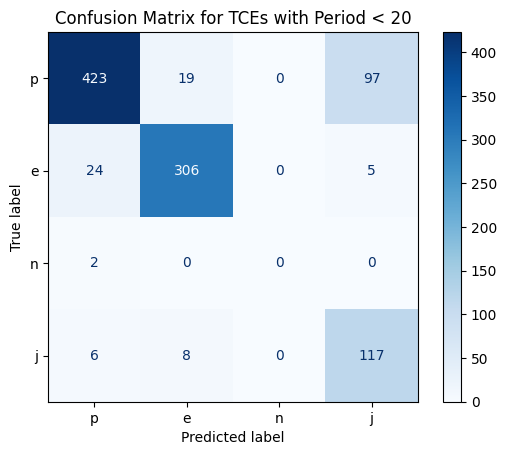

In [26]:
# Extra: Make the Precision Recall and Confusion matrix only for elements with short periods

# Make PR curve with Scikit learn

from sklearn.metrics import precision_recall_curve, roc_curve, confusion_matrix, auc
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay

# Create a boolean mask for rows where 'Per' > 20 for each Astro ID in tce_labels
long_period=20
mask = tce_table.loc[tce_labels.index, 'Per'] < long_period
filtered_tce_labels = tce_labels[mask]

# i = 0 # i is the ensemble idx out of 10

ytrue_short = []
ypred_short = []
astro_id_preds = []
tic_id_preds = []
for astro_id in filtered_tce_labels.index:
    try:
        # ypred.append(np.max(np.array([ensemble_preds[i].loc[astro_id].values for i in range(nruns)]), axis=0)) # i is the ensemble idx out of 10
        ypred_short.append(np.mean(np.array([ensemble_preds[i].loc[astro_id].values for i in range(nruns)]), axis=0))

        ytrue_short.append(tce_labels.loc[astro_id].values[:-1])

        astro_id_preds.append(astro_id)
        tic_id_preds.append(tce_labels.loc[astro_id].values[-1])
        # ypred.append(ensemble_preds[i].loc[astro_id].values)
    except Exception as e:
        print("ERROR: No object.", e)
        continue


ytrue_short = np.array(ytrue_short).astype(bool)
ypred_short = np.array(ypred_short)

# PR curve
plt.figure()
for l, label in enumerate(labels):
    precision, recall, thresholds = precision_recall_curve(ytrue_short[:,l], ypred_short[:,l])
    auc_val = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label.split('_')[-1]} ({auc_val:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title('Precision-Recall Curve for TCEs with Period < 20')

# ROC curve
plt.figure()
for l, label in enumerate(labels):
    fpr, tpr, thresholds = roc_curve(ytrue_short[:,l], ypred_short[:,l])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label.split('_')[-1]} ({auc_val:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title('ROC Curve for TCEs with Period < 20')

# # Confusion Matrix
# plt.figure()
# cm = confusion_matrix(ytrue.argmax(axis=1),ypred.argmax(axis=1))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label.split('_')[-1] for label in labels])
# disp.plot(cmap=plt.cm.Blues)
# plt.title('Confusion Matrix for TCEs with Period > 20')


# Confusion Matrix
plt.figure()
cm = confusion_matrix(ytrue_short.argmax(axis=1), ypred_short.argmax(axis=1))

# Get unique classes present in the filtered data
present_classes = np.unique(ytrue.argmax(axis=1))
filtered_labels = [labels[i].split('_')[-1] for i in present_classes]  # Filter only present class labels

# Plot the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=filtered_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for TCEs with Period < 20')


In [27]:
labels

['disp_p', 'disp_e', 'disp_n', 'disp_j']

Text(0.5, 1.0, 'Precision-Recall Curve for TCEs with Period > 20 and All Periods')

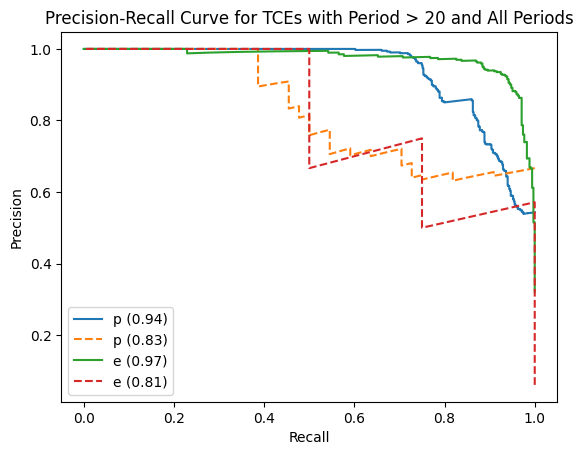

In [28]:
import json
pr_data = {}

#Make a plot superposing the PR curve for y_pred y_true and y_pred_long y_true_long
plt.figure()
labels_joined_plot=['p','e']
for l, label in enumerate(labels_joined_plot):
    precision, recall, thresholds = precision_recall_curve(ytrue[:,l], ypred[:,l])


    auc_val = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label.split('_')[-1]} ({auc_val:.2f})")
    precision_long, recall_long, thresholds_long = precision_recall_curve(ytrue_long[:,l], ypred_long[:,l])
    auc_val_long = auc(recall_long, precision_long)
    plt.plot(recall_long, precision_long, label=f"{label.split('_')[-1]} ({auc_val_long:.2f})", linestyle='dashed')

    pr_data[label] = {
        'precision': precision.tolist(),
        'recall': recall.tolist(),
        'precision_long': precision_long.tolist(),
        'recall_long': recall_long.tolist(),
    }
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title('Precision-Recall Curve for TCEs with Period > 20 and All Periods')



# # Save PR data to JSON file
# file_name = "pr_data_jan.json"  # Change name if saving for another month
# with open(file_name, "w") as f:
#     json.dump(pr_data, f, indent=4)

# print(f"Precision-Recall data saved to {file_name}")


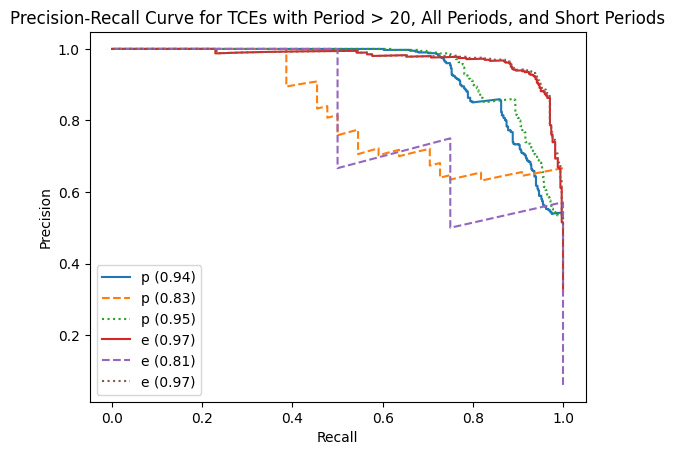

Precision-Recall data saved to pr_data_noreshuffle_oldmodel-jan_threesplit.json


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Initialize dictionary to store PR data
pr_data = {}

# Make a plot superposing the PR curve for y_pred y_true, y_pred_long y_true_long, and y_pred_short y_true_short
plt.figure()
labels_joined_plot = ['p', 'e']

for l, label in enumerate(labels_joined_plot):
    # Compute PR curve for all periods
    precision, recall, thresholds = precision_recall_curve(ytrue[:, l], ypred[:, l])
    auc_val = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label.split('_')[-1]} ({auc_val:.2f})")

    # Compute PR curve for long-period cases
    precision_long, recall_long, thresholds_long = precision_recall_curve(ytrue_long[:, l], ypred_long[:, l])
    auc_val_long = auc(recall_long, precision_long)
    plt.plot(recall_long, precision_long, label=f"{label.split('_')[-1]} ({auc_val_long:.2f})", linestyle='dashed')

    # Compute PR curve for short-period cases
    precision_short, recall_short, thresholds_short = precision_recall_curve(ytrue_short[:, l], ypred_short[:, l])
    auc_val_short = auc(recall_short, precision_short)
    plt.plot(recall_short, precision_short, label=f"{label.split('_')[-1]} ({auc_val_short:.2f})", linestyle='dotted')

    # Store PR data in dictionary
    pr_data[label] = {
        'precision': precision.tolist(),
        'recall': recall.tolist(),
        'precision_long': precision_long.tolist(),
        'recall_long': recall_long.tolist(),
        'precision_short': precision_short.tolist(),
        'recall_short': recall_short.tolist(),
    }

# Labels and title for the plot
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title('Precision-Recall Curve for TCEs with Period > 20, All Periods, and Short Periods')
plt.show()

# Save PR data to JSON file
# file_name = "pr_data_noreshuffle_oldmodel-jan_threesplit.json"  # Change name if saving for another month
# with open(file_name, "w") as f:
#     json.dump(pr_data, f, indent=4)

# print(f"Precision-Recall data saved to {file_name}")


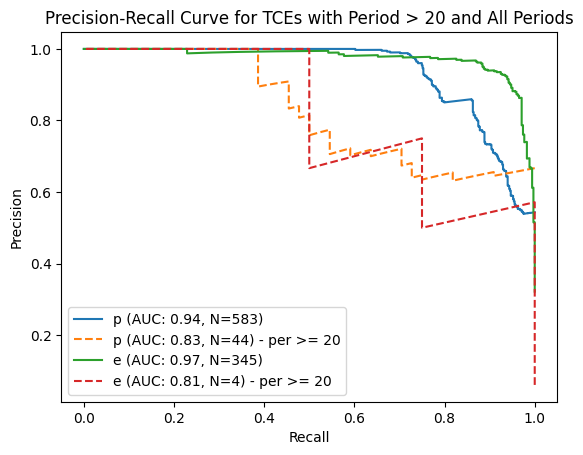

In [40]:
# Make a plot superposing the PR curve for y_pred y_true and y_pred_long y_true_long
plt.figure()
labels_joined_plot = ['p', 'e']  # Labels to plot

for l, label in enumerate(labels_joined_plot):
    # Compute PR curve for all periods
    precision, recall, thresholds = precision_recall_curve(ytrue[:, l], ypred[:, l])
    auc_val = auc(recall, precision)
    num_events = np.sum(ytrue[:, l])  # Count number of positive samples
    plt.plot(recall, precision, label=f"{label.split('_')[-1]} (AUC: {auc_val:.2f}, N={num_events})")

    # Compute PR curve for long-period cases
    precision_long, recall_long, thresholds_long = precision_recall_curve(ytrue_long[:, l], ypred_long[:, l])
    auc_val_long = auc(recall_long, precision_long)
    num_events_long = np.sum(ytrue_long[:, l])  # Count number of positive samples in long periods
    plt.plot(recall_long, precision_long, label=f"{label.split('_')[-1]} (AUC: {auc_val_long:.2f}, N={num_events_long}) - per >= {long_period}", linestyle='dashed')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title('Precision-Recall Curve for TCEs with Period > 20 and All Periods')

plt.show()


In [ ]:
precision

In [ ]:
pr_data_feb['p']['precision']

In [39]:
len(pr_data_feb['p']['recall'])

1066

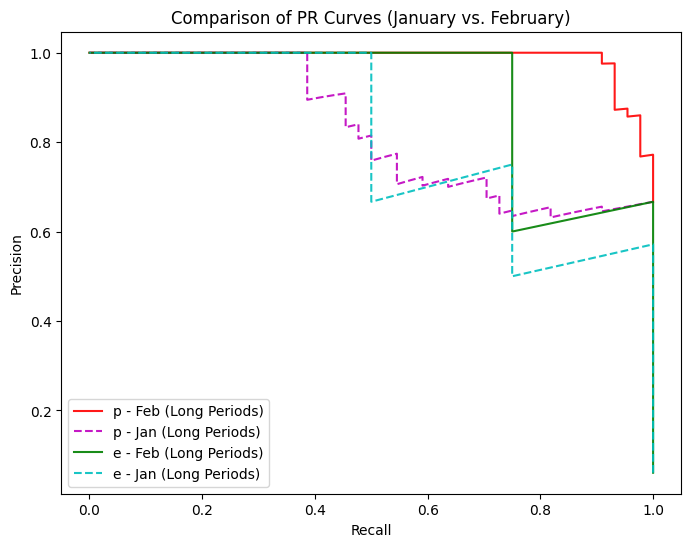

In [42]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Function to load PR data from JSON
def load_pr_data(file_name):
    with open(file_name, "r") as f:
        return json.load(f)

# Load the PR data from both months
file_feb = "pr_data_noreshuffle_fullmodel-feb_threesplit.json"
file_jan = "pr_data_noreshuffle_oldmodel-jan_threesplit.json"

pr_data_feb = load_pr_data(file_feb)
pr_data_jan = load_pr_data(file_jan)

# Initialize the plot
plt.figure(figsize=(8, 6))
colors = ['b', 'r', 'g', 'm', 'c', 'y', 'k']  # Added more colors for variety

for i, label in enumerate(pr_data_feb.keys()):
    # Load February data
    precision_feb = np.array(pr_data_feb[label]["precision"])
    recall_feb = np.array(pr_data_feb[label]["recall"])
    precision_long_feb = np.array(pr_data_feb[label]["precision_long"])
    recall_long_feb = np.array(pr_data_feb[label]["recall_long"])
    precision_short_feb = np.array(pr_data_feb[label]["precision_short"])
    recall_short_feb = np.array(pr_data_feb[label]["recall_short"])

    # Load January data
    precision_jan = np.array(pr_data_jan[label]["precision"])
    recall_jan = np.array(pr_data_jan[label]["recall"])
    precision_long_jan = np.array(pr_data_jan[label]["precision_long"])
    recall_long_jan = np.array(pr_data_jan[label]["recall_long"])
    precision_short_jan = np.array(pr_data_jan[label]["precision_short"])
    recall_short_jan = np.array(pr_data_jan[label]["recall_short"])

    # Count the number of positive samples (length of recall)
    num_samples_feb = len(recall_feb)
    num_samples_long_feb = len(recall_long_feb)
    num_samples_short_feb = len(recall_short_feb)

    num_samples_jan = len(recall_jan)
    num_samples_long_jan = len(recall_long_jan)
    num_samples_short_jan = len(recall_short_jan)

    # # Plot both for long-period cases
    plt.plot(recall_long_feb, precision_long_feb, linestyle="-", color=colors[(i + 1)], alpha=0.9,
             label=f"{label} - Feb (Long Periods)")
    plt.plot(recall_long_jan, precision_long_jan, linestyle="--", color=colors[(i + 3)], alpha=0.9,
             label=f"{label} - Jan (Long Periods)")

    # Plot both for short-period cases
    # plt.plot(recall_short_feb, precision_short_feb, linestyle="-", color=colors[(i + 1)], alpha=0.9,
    #          label=f"{label} - Feb (Short Periods)")
    # plt.plot(recall_short_jan, precision_short_jan, linestyle="--", color=colors[(i + 3)], alpha=0.9,
    #          label=f"{label} - Jan (Short Periods)")

# Labels and title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Comparison of PR Curves (January vs. February)")

# Show the plot
plt.show()


In [ ]:
# np.sum(ytrue, axis=1)
tce_labels.head(6) # TODO: Some objects have multiple labels or no labels - how to assess metrics?

disp_p
0.5573159366262814 1.0 0.0
0.5561797752808989 0.9933110367892977 3.105144e-39
0.555763823805061 0.9916387959866221 1.7080873e-22
0.5562851782363978 0.9916387959866221 3.6764046e-22
0.5558685446009389 0.9899665551839465 1.6670379e-19
0.5554511278195489 0.9882943143812709 2.1893685e-19
0.555032925682032 0.9866220735785953 3.1143614e-19
0.5555555555555556 0.9866220735785953 5.7759296e-17
0.5560791705937794 0.9866220735785953 2.8895666e-16
0.5556603773584906 0.9849498327759197 1.5571038e-13
0.5552407932011332 0.9832775919732442 6.6740195e-13
0.555765595463138 0.9832775919732442 3.023554e-12
0.5553453169347209 0.9816053511705686 1.6988667e-11
0.5549242424242424 0.979933110367893 1.1152752e-10
0.5554502369668246 0.979933110367893 1.5443353e-09
0.5559772296015181 0.979933110367893 1.7943496e-09
0.5565052231718899 0.979933110367893 1.6283722e-07
0.5570342205323194 0.979933110367893 2.391037e-07
0.5575642245480494 0.979933110367893 2.4417974e-07
0.5571428571428572 0.9782608695652174 2.81

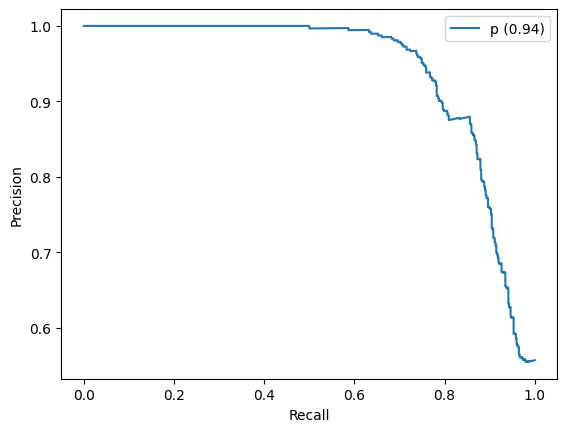

In [ ]:
# PR curve
plt.figure()
for l, label in enumerate(labels):
    print(label)
    precision, recall, thresholds = precision_recall_curve(ytrue[:,l], ypred[:,l])
    auc_val = auc(recall, precision)
    plt.plot(recall, precision, label=f"{label.split('_')[-1]} ({auc_val:.2f})")
    if label == 'disp_p':
        break
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

for i in range(len(thresholds)):
    print(precision[i], recall[i], thresholds[i])

In [ ]:
# Counts
tce_labels.sum()

In [ ]:
from matplotlib import pyplot as plt

ps, rs, ths = ([], [], [])
th = np.max(pred_es)
while th >= 0.0:
    p, r = pr_at_th(th)
    ps.append(p)
    rs.append(r)
    ths.append(th)
    th -= 0.0005

from sklearn import metrics

print(f'AUC: {metrics.auc(rs, ps)}, max R: {max(rs)}, max P: {max(ps)}')

i = len(rs) - 1
while rs[i] == 1.0:
    i -= 1
i += 1
print(f'100% recall at: {int(ps[i] * 100)}%, threshold: {ths[i]}')

fig, ax = plt.subplots(figsize=(6, 3.7), dpi=200)

ax.spines['top'].set_color('#808080')
ax.spines['right'].set_color('#808080')
ax.spines['left'].set_color('#808080')
ax.spines['bottom'].set_color('#808080')
ax.tick_params(direction='in', color='#808080')

plt.grid(color='#c0c0c0', linestyle='--', linewidth=0.5)

plt.ylabel('Precision', fontweight='bold')
plt.xlabel('Recall', fontweight='bold')

# plt.xlim((0.0, 1.0))
# plt.ylim((0.0, 1.0))

_ = plt.plot(rs, ps)

In [ ]:
i = 0
while ps[i] > 0.749:
    i += 1
print(f'74.9% precision at: {int(rs[i] * 100)}%, threshold: {ths[i]}')

In [ ]:
# # Get data
# from astronet import models
# from astronet.astro_cnn_model import input_ds

# model_name = 'AstroCNNModelVetting'
# config_name = 'base_new'
# labels = ['p', 'e', 'n', 'j']
# config = models.get_model_config(model_name, config_name)

# ds = input_ds.build_dataset(
#       file_pattern=file_pattern,
#       input_config=config.inputs,
#       batch_size=1,
#       include_labels=False,
#       shuffle_filenames=False,
#       repeat=1,
#       include_identifiers=True)
# labels_ds = input_ds.build_dataset(
#       file_pattern=file_pattern,
#       input_config=config.inputs,
#       batch_size=1,
#       include_labels=True,
#       shuffle_filenames=False,
#       repeat=1,
#       include_identifiers=True)
# labels_iter = iter(labels_ds)


In [ ]:
# Plot example light curves
ds = ds.cache()
def plot_ds_tce(ds, astro_id):
    for d in ds:
        if d[1] == astro_id:
            for k, v in d[0].items():
                if k.startswith('local_'):
                    continue
                if k.startswith('global_'):
                    continue
                if k.startswith('secondary_'):
                    continue
                if k.startswith('sample_'):
                    continue
                print(f'{k:25}: {v.numpy()}')
            global_view = np.array(d[0]['global_view'][0].numpy())
            local_view = np.array(d[0]['local_view'][0].numpy())
            secondary_view = np.array(d[0]['secondary_view'][0].numpy())
            fig, axes = plt.subplots(2, 3, figsize=(14, 5))
            axes[0, 0].plot(global_view, '.-')
            axes[0, 1].plot(local_view, '.-')
            axes[0, 2].plot(secondary_view, '.-')
            axes[1, 0].plot(d[0]['global_mask'][0].numpy(), '.-')
            axes[1, 1].plot(d[0]['global_view_0.3'][0].numpy(), '.-')
            axes[1, 2].plot(d[0]['global_view_5.0'][0].numpy(), '.-')

            # plt.show()
            # plt.close('all')
            plt.tight_layout()
            return fig, axes

In [ ]:
pl.loc[573]

In [ ]:
# Examine misclassifications
for i, astro_id in enumerate(astro_id_preds):
    if ytrue[i].argmax() != ypred[i].argmax():
        print(i, "Astro ID:", astro_id, "|| TIC ID:", tic_id_preds[i], "|| True label:", ytrue[i], "|| Max predicted prob:", ypred[i].round(2))
        print(pl.loc[astro_id])

        fig, axes = plot_ds_tce(ds, astro_id)
        axes[0, 0].set_title(f"Astro ID: {astro_id} TIC ID: {tic_id_preds[i]}")
        axes[0, 1].set_title(f"True label: {labels[ytrue[i].argmax()]} Predicted label: {labels[ypred[i].argmax()]}")
        plt.show()
